#
## <center>**AWS re/Start Cloud Computing with AI Bootcamp**</center>

### <center> **WAES Mini Project - Handwritten Digit Classifier** </center>

<center>by</center>

#### <center>**Kweku Esuon Acquaye**</center>

### **Table of Contents**

* Section 1: Introduction
  * Section 1.1: Project Scope
  * Section 1.2: Data Sourcing and Gathering - Used Dataset(s)
* Section 2: Preliminary Data Exploration
  * Section 2.1: The Dataset
  * Section 2.2: Matrix Rendering / Representation for Machine Learning (ML)
* Section 3: Load Data and Preprocess
  * Section 3.1: Implementation
  * Section 3.2: Preprocess Data
* Section 4: ML / NN Engineering
    * Section 4.1: Create / Build Neural Network (NN) Model
    * Section 4.2: Optimising Hyperparameters
* Section 5: Model Training and Testing
  * Section 5.1: Model Training
  * Section 5.2: Model Testing and Evaluation
* Section 6: Visualisation of Training Progress and Test Set Evaluation
  * Section 6.1: Plots of Training Accuracy and Training Loss
  * Section 6.2: Visualisation of Model Evaluation
* Section 7: Take Input from User and Classify
  * Section 7.1: On Local Device
  * Section 7.2: On Google Colab
* Section 8: Conclusion<br>
<br>
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
<br>

#### **Declaration:**
Some of the code used in this mini-project has been adapted and customised from https://docs.python.org/, https://pandas.pydata.org/docs, https://scikit-learn.org/stable/auto_examples/, https://matplotlib.org/stable/, https://stackoverflow.com/questions/, https://geeksforgeeks.org/, https://kaggle.com/, https://numpy.org/doc/stable/user/, https://github.com/, https://langdev.stackexchange.com/, and from popular Foundation Models.<br>

## **Section 1: Introduction**<br>

This notebook presents a mini-project developed during _AWS re/Start Cloud Computing with AI Bootcamp_ on an individual basis. Other projects developed in group collaboration demonstrating teamwork are presented in other repositories.<br>
<br>
### **Section 1.1: Project Scope**<br>
**Title:** Handwritten Digit Classifier<br>
<br>

**Problem Statement:**<br>
Create a machine learning model that can recognise handwritten digits (0–9) using the MNIST dataset.<br>

Your program should load the dataset, preprocess the images, train a classification model, and evaluate its accuracy.<br>

The application must allow the user to input a digit (either drawn or uploaded as an image) and display the model’s predicted number.
<br>
**-- End of Problem Statement --**

<br>
In summary, this is a multi-class classification problem with 10 output classes, one for each digit, that lends itself well to solving by an artificial neural network.<br>

<br>

### **Section 1.2: Data Sourcing and Gathering - Used Dataset(s)**<br>
The entire dataset was obtained directly from the handwritten digit dataset from MNIST (Modified National Institute of Standards and Technology) database. No other sourcing, gathering, curating, merging, etc was done by this analyst.<br>

<br>


## **Section 2: Preliminary Data Exploration**<br>

### **Section 2.1: The Dataset**
  
The original dataset consists of 70,000 handwritten digits (0–9) with each example represented as an image of 28 x 28 greyscale pixels. For effective model performance, I utilise scripting to shuffle and split this into:
* a training set of 60,000 images.
* a test set of 10,000 images.

### **Section 2.2: Matrix Encoding / Representation for Machine Learning (ML) and Neural Networks (NN)**

* Each original image is a 28 x 28 pixel map, and each pixel is encoded as an 8-bit integer between 0 and 255. In standard digital image processing of greyscale, 0 represents black and 255 represents white, with various gradients of grey between 0 and 255. In the MNIST dataset however, this convention is inverted, i.e. 0 represents white and 255 represents black, with corresponding gradient of grey between them. This inversion is because the original handwritten digits were written with dark ink on light paper, and in many ML and NN frameworks, it is more intuitive to treat the "empty" background as zero and the "active" pen strokes as high-intensity signals. Sometimes some visualisation software like _matpoltlib_ maps the raw MNIST data encoding (where ink is 255) back to the standard digital display scale (where 255 is light).
* To enable ML operations, greyscale images are typically represented as 2-D arrays (matrices), while colour images are represented as 3-D arrays (tensors) where the extra dimension accounts for the three colour channels (RGB). For the sake of consistency, modern ML frameworks represent greyscale as 3-D tensors where the colour dimension is 1, with shape example: [1, 28, 28], whereas the colour dimesion of colour images is 3, shape example: [3, 28, 28].
* Because the model built in this task is not a Convolutional Neural Network (CNN), matrix representation remains only at the pixel map level, i.e. no 2-D matrices or 3-D tensors are fed into the NN model itself. Instead, the _normalised_ pixel map representation is _flattened_ and fed into the model as a 1-D _vector_. 

The following visualisation shows the digit `1` and it's _normalised_ matrix representation in a 14 x 14 pixel map:<br>

![Two inline images - a fuzzy digit '1', and a 14 x 14 floating-point matrix representation](https://www.tensorflow.org/images/MNIST-Matrix.png)

## **Section 3: Load Data and Preprocess**<br>

### **Section 3.1: Implementation**<br>
For the purpose of portability, a Scikit-Learn ML model is implemented here rather than the TensorFlow and Keras model (downloaded and modified earlier in July 2022) to facilitate easier compatibility with local device Jupyter execution environments.<br>

### **Section 3.2: Preprocess Data**<br>


In [3]:
# Import libraries
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Adjust output granularity
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

# Improve formatting of NumPy arrays
np.set_printoptions(linewidth = 200)

# Output to indicate successful execution of cell script
print("Modules imported.")

Modules imported.


In [4]:
# Begin sclearn implementation
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load MNIST dataset
print('Loading MNIST dataset ... please be patient, this might take a bit ... \n')
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Extract features and labels
X, y = mnist.data, mnist.target

# Normalise pixel values, i.e. 0 to 1 range
X_normalized = X / 255.0

# Convert labels to integers
y = y.astype(int)

# Shuffle images and split into training and testing sets - 60,000 and 10,000 respectively
x_train_sk, x_test_sk, y_train_sk, y_test_sk = train_test_split(
    X_normalized, y, test_size=10000, train_size=60000, random_state=42, stratify=y
)

# Output to screen
print('Data loading and preprocessing complete.')
print(f'Training set shape: {x_train_sk.shape}')
print(f'Testing set shape: {x_test_sk.shape}')

Loading MNIST dataset ... please be patient, this might take a bit ... 

Data loading and preprocessing complete.
Training set shape: (60000, 784)
Testing set shape: (10000, 784)


## **Section 4: ML / NN Engineering**

### **Section 4.1: Create / Build NN Model**

Here an _sklearn.neural_network.MLPClassifier_ is used to build a NN for the task. It is a multi-layer perceptron (MLP) algorithm, a type of supervised feedforward artificial neural network model.
* The _MLPClassifier_ trains using backpropagation, i.e. iteratively computes partial derivatives of the loss function to update the model parameters.
* It utilises non-linear activation functions on fully connected nodes (neurons, perceptrons) of hidden layers.
* Limitation - not ideal for large-scale applications but rather for small-to-medium-sized datasets.
* Supports algorithms like SGD (Stochastic Gradient Descent) and L-BFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) to optimise the loss function. Here _Adam_ is utilised for reasons explained later below.
* Although not necessary, I define and use the equivalent of a _callback function_ to terminate training once a predetermined training accuracy level is reached. The advantage of this is that it prevents overfitting, and reduces the final model size. It also provides real-time monitoring and logging by tracking metrics.


In [5]:
# Define callback function
def train_with_stopping_criteria(model, train_features, train_labels, target_accuracy=0.995, max_epochs=50):
    """Train the MLPClassifier and stop if target accuracy is reached."""
    loss_history = []
    accuracy_history = []
    classes = np.unique(train_labels)

    print(f'Starting training with target accuracy: {target_accuracy*100}%\n... please be patient, this might take a bit ...\n')

    for epoch in range(max_epochs):
        # Perform one iteration of training
        model.partial_fit(train_features, train_labels, classes=classes)

        # Track metrics
        current_loss = model.loss_
        y_pred = model.predict(train_features)
        current_acc = accuracy_score(train_labels, y_pred)

        loss_history.append(current_loss)
        accuracy_history.append(current_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1}: Loss = {current_loss:.4f}, Accuracy = {current_acc:.4f}')

        # Check stopping criteria
        if current_acc >= target_accuracy:
            print(f'\nReached {target_accuracy*100}% accuracy so cancelling training!')
            break

    return model, loss_history, accuracy_history

# Output to indicate successful execution of cell script
print("The equivalent of a callback function is created.")

The equivalent of a callback function is created.


### **Section 4.2: Optimising Hyperparameters**<br>

By relying on informed basic skills, extensive experimentation was performed to obtain the best / optimum model performance / parameters (i.e. weights and bias) by tuning the following hyperparameters through trial and error:<br>

* **Batch Size:** The number of training samples processed before the model updates its internal weights. Smaller batches result in unstable 'zigzag' path to convergence, while larger batches can be smoother but computationally taxing and only recommended in high performance systems. The original batch size of 4,000 was eventually used.
* **Learning Rate (lr):** dictates the speed with which the model updates its weights. High lr updates and learns quickly but might miss the best solution, while low lr might take forever and may not even converge, or converge on local minima rather than global minima, or may get stuck in saddle points (flat plateaus). An lr of 0.003 proved to the best for this model.
* **Epochs:** The number of times the entire training dataset is passed through the neural network. More epochs allow more learning but increase the risk of overfitting. For small to medium sized datasets, 30 to 50 epochs is often adequate. Although 50 epochs was specified, I also implemented a callback function to stop training when an accuracy of 99.5% was attained regardless of epoch number.
* **Loss Function:** Determines the magnitude of the error between a model's prediction and the actual value. It basically tells the model how good or bad its prediction was. Examples include Mean Squared Error (MSE), Mean Absolute Error (MAE),  Binary Cross-Entropy (BCE), and Categorical Cross-Entropy (CCE). The loss function utilised in this model is _cross-entropy loss_ because, in addition to being a standard choice for multi-class classification problems whose output is a probability value between 0 and 1, sklearn's _MLPClassifier_ defaults to using cross-entropy when the solver (i.e. optimiser) is set to 'Adam'.
* **Optimiser:** Mathematical functions that minimise prediction errors by adjusting the learning process based on loss function gradients. Choosing the right optimiser depends on the particular problem being solved, the model architecture, other considerations, and some informed experimentation. The right optimiser can also add "velocity" or "momentum" to overide problems presented by low learning rates. Examples of optimisers include SGD (stochastic gradient descent), RMSprop, and Adagrad. Adam (Adaptive Moment Estimation), and Nadam (Nesterov-accelerated Adaptive Moment Estimation) partucularly incorporate a "momentum" term to carry over velocity in the direction of the gradient. In this instance, Adam optimiser is used because it is generally computationally efficient and requires little memory, combining the advantages of two other extensions of SGD: AdaGrad and RMSProp.
* **Activation Function:** Most activation functions introduce non-linearity to the model from one layer to the next. It defines how a neuron's weighted input is converted into an output, and maximises important information while diminishing irrelevant features. Examples include Sigmoid/Logistic, ReLU, Tanh, Leaky ReLU, and Softmax. After some experimentation, ReLU activation used in the the original model proved to be best, and is utilised in this model. It is an effective choice for hidden layers in NNs known for avoiding the _Vanishing Gradient Problem_.
* **Layers and Hidden Layers:** In addition to input and output layers, hidden layers determine the depth of NNs and enable learning of more complex patterns. After much experimentation, two hidden layers were obtained to be optimum in this architecture.
* **Nodes/Neurons:** Processing units that are architectured in layers, with their deployed numbers being important. After much experimentation, 256 nodes and 128 nodes in the first and the second hidden layers respectively were obtained to be optimum in this model.<br>

_**Note:**_<br>
1. **Model hyperparameters:** Human developer-controlled input settings that guide the learning process. Examples are as above. Model hyperparameters are input before training the model.
2. **Model parameters:** Model algorithm-controlled properties representing anything that the model 'learns' from the data during the training process, and uses to make predictions or decisions. The commonest examples are weights and biases. In addition to these, different machine learning models yield different parameters, e.g. centroids in K-means clustering, and decision boundaries (hyperplanes) in SVMs (Support Vector Machines). Model parameters are obtained after model training.

In [6]:
# Create NN model of modular functions and experiment with hyperparameters for best performance
def create_model(my_learning_rate):
    """Create and configure an MLPClassifier as a neural network (NN)"""
    # hidden_layer_sizes=(256, 128) matches the original units=256 and units=128
    # max_iter=50 matches the original epochs
    model = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        learning_rate_init=my_learning_rate,
        max_iter=50,
        batch_size=4000,
        random_state=42,
        verbose=True
    )
    return model

# Output to indicate successful execution of cell script
print("Model created.")

Model created.


In [7]:
# Define model training
def train_model(model, train_features, train_labels, epochs):
    """Train the MLPClassifier manually using partial_fit to track metrics."""
    loss_history = []
    accuracy_history = []
    classes = np.unique(train_labels)

    print(f"Training model for {epochs} epochs...")

    for i in range(epochs):
        # partial_fit performs one iteration of stochastic gradient descent
        # classes must be provided on the first call
        model.partial_fit(train_features, train_labels, classes=classes)

        # Track loss and accuracy
        current_loss = model.loss_
        y_pred_train = model.predict(train_features)
        current_accuracy = accuracy_score(train_labels, y_pred_train)

        loss_history.append(current_loss)
        accuracy_history.append(current_accuracy)

        if (i + 1) % 5 == 0 or i == 0:
            print(f"Iteration {i+1}/{epochs} - Loss: {current_loss:.4f}, Accuracy: {current_accuracy:.4f}")

    return model, loss_history, accuracy_history

# Output to indicate successful execution of cell script
print("Model training defined.")

Model training defined.


## **Section 5: Model Training and Testing**

In this section, the model is trained to >= 99.5% accuracy and then tested to determine performance on not-yet-seen images.

### **Section 5.1: Model Training**

In [8]:
# Train NN model

# Initialize MLP model with specified learning rate
learning_rate = 0.003
my_sklearn_model = create_model(learning_rate)

# Train model with callback at 99.5% accuracy
my_sklearn_model, loss_history, accuracy_history = train_with_stopping_criteria(
    my_sklearn_model,
    x_train_sk,
    y_train_sk,
    target_accuracy=0.995,
    max_epochs=50
)

# Output to screen
print('\nProcess finished.')
print(f'Total iterations: {len(loss_history)}')
print(f'Final Accuracy reached: {accuracy_history[-1]*100:.2f}%')

Starting training with target accuracy: 99.5%
... please be patient, this might take a bit ...

Iteration 1, loss = 0.82542501
Epoch 1: Loss = 0.8254, Accuracy = 0.9057
Iteration 1, loss = 0.28600091
Iteration 1, loss = 0.19840675
Iteration 1, loss = 0.15138581
Iteration 1, loss = 0.12088333
Epoch 5: Loss = 0.1209, Accuracy = 0.9696
Iteration 1, loss = 0.09900135
Iteration 1, loss = 0.08202901
Iteration 1, loss = 0.06883181
Iteration 1, loss = 0.05882909
Iteration 1, loss = 0.05117427
Epoch 10: Loss = 0.0512, Accuracy = 0.9853
Iteration 1, loss = 0.04593729
Iteration 1, loss = 0.04274564
Iteration 1, loss = 0.04111269
Iteration 1, loss = 0.03821491
Iteration 1, loss = 0.03179131
Epoch 15: Loss = 0.0318, Accuracy = 0.9891
Iteration 1, loss = 0.02973743
Iteration 1, loss = 0.02580713
Iteration 1, loss = 0.02588717

Reached 99.5% accuracy so cancelling training!

Process finished.
Total iterations: 18
Final Accuracy reached: 99.63%


In [9]:
# Calculate and output final metrics from the training history
final_loss = loss_history[-1]
final_accuracy = accuracy_history[-1] * 100

print(f'Final Training Loss: {final_loss:.4f}')
print(f'Final Training Accuracy: {final_accuracy:.2f}%')

Final Training Loss: 0.0259
Final Training Accuracy: 99.63%


### **Section 5.2: Model Testing and Evaluation (with Test Set)**

In [10]:
# Use model to predict labels for the entire test set
y_pred_test = my_sklearn_model.predict(x_test_sk)

# Calculate overall accuracy
test_accuracy = accuracy_score(y_test_sk, y_pred_test)

print(f"--- Test Set Evaluation ---")
print(f"Total Test Images: {len(x_test_sk)}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Display detailed metrics per digit
print("\nClassification Report:")
print(classification_report(y_test_sk, y_pred_test))

--- Test Set Evaluation ---
Total Test Images: 10000
Test Accuracy: 97.60%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       986
           1       0.98      0.99      0.99      1125
           2       0.98      0.98      0.98       999
           3       0.97      0.98      0.97      1020
           4       0.98      0.97      0.98       975
           5       0.98      0.97      0.97       902
           6       0.99      0.99      0.99       982
           7       0.98      0.97      0.98      1042
           8       0.97      0.96      0.97       975
           9       0.94      0.97      0.96       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



The displayed _Test Accuracy_ above, together with the other metrics shown, is the actual measure of this model's _performance_, since this is for data not seen during training.

## **Section 6: Visualisation of Training Progress and Test Set Evaluation**<br>

### **Section 6.1: Plots of Training Accuracy and Training Loss**


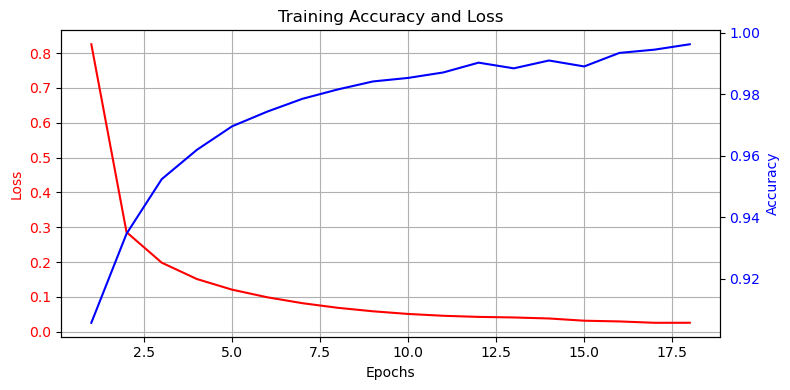

In [11]:
# Visualise training progress

# Create a single figure and axis
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot Training Loss on the primary y-axis
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='red')
ax1.plot(range(1, len(loss_history) + 1), loss_history, color='red', label='Loss')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True)

# Create a secondary y-axis for Training Accuracy
ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='blue')
ax2.plot(range(1, len(accuracy_history) + 1), accuracy_history, color='blue', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='blue')

# Add title and layout
plt.title('Training Accuracy and Loss')
fig.tight_layout()
plt.show()

### **Section 6.2: Visualisation of Model Evaluation**

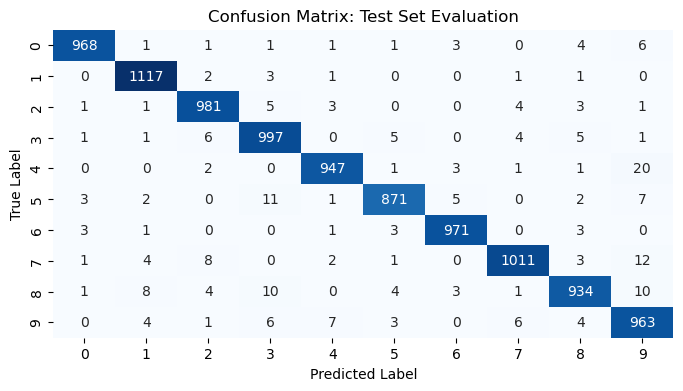

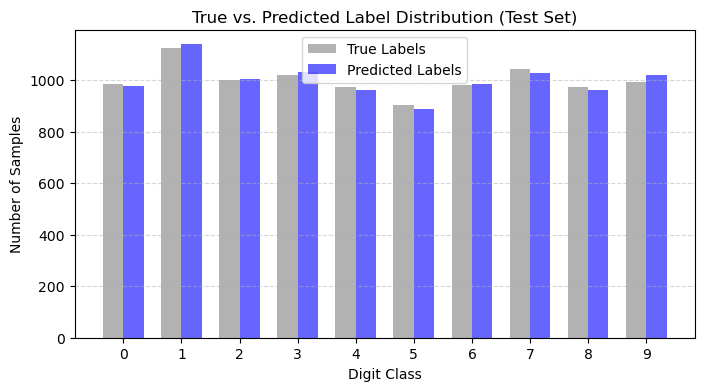

In [12]:
# Visualise test set evaluation
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test_sk, y_pred_test)

# Plot confusion matrix
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Test Set Evaluation')
plt.show()

# Space between plots for clarity
print("\n")

# Plot the distribution of true vs predicted labels
plt.figure(figsize=(8, 4))
unique, counts_true = np.unique(y_test_sk, return_counts=True)
unique, counts_pred = np.unique(y_pred_test, return_counts=True)

bar_width = 0.35
plt.bar(unique - bar_width/2, counts_true, bar_width, label='True Labels', color='gray', alpha=0.6)
plt.bar(unique + bar_width/2, counts_pred, bar_width, label='Predicted Labels', color='blue', alpha=0.6)

plt.xlabel('Digit Class')
plt.ylabel('Number of Samples')
plt.title('True vs. Predicted Label Distribution (Test Set)')
plt.xticks(unique)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## **Section 7: Take Input from User and Classify**
The code in this section enables users to load handwritten digit images that are then automatically run through the model for classification.

### **Section 7.1: On Local Device**
If you  are running this notebook on Google Colab, then please comment out this sub-section (select all, then Ctrl + / ) and go to Section 7.2.

This sub-section utilises _tkinter_ to open a local file dialog for selecting images, making this notebook more portable for local Jupyter environments.<br>

Please note that _tkinter_ requires an enabled local display to open the dialog window.

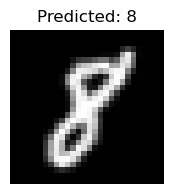

In [13]:
# Import dependencies
import PIL
import tkinter as tk
from PIL import Image
from tkinter import filedialog

def classify_local_images(model):
    """Setup a hidden tkinter root window for the file dialog"""
    root = tk.Tk()
    root.withdraw()
    # Ensure the dialog appears on top
    root.call('wm', 'attributes', '.', '-topmost', True)

    file_paths = filedialog.askopenfilenames(title="Select hand-drawn digit images",
                                            filetypes=[("Image files", "*.png *.jpg *.jpeg *.bmp")])

    if not file_paths:
        print("No files selected.")
        return

    for path in file_paths:
        img = Image.open(path).convert('L')
        img = img.resize((28, 28))
        img_array = np.array(img)

        if img_array[0,0] > 127:
            img_array = 255 - img_array

        img_array = img_array / 255.0
        # Flatten the image to 1D (1, 784) for Scikit-Learn
        img_input = img_array.reshape(1, -1)

        # Scikit-Learn returns the class directly
        predicted_digit = model.predict(img_input)[0]

        plt.figure(figsize=(2,2))
        plt.imshow(img_array, cmap='gray')
        plt.title(f"Predicted: {predicted_digit}")
        plt.axis('off')
        plt.show()

    root.destroy()

# Run locally
classify_local_images(my_sklearn_model)

In [14]:
# Save trained model using joblib for export
# Run this cell only if you want to save and export your own model after desired changes

import joblib
joblib.dump(my_sklearn_model, 'my_sklearn_model.joblib')

# Output to indicate successful execution of cell script
print("Model saved successfully.")

Model saved successfully.


In [15]:
# Check and confirm model size
path = "my_sklearn_model.joblib"
size_mb = os.path.getsize(path) / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model size: 7.18 MB


In [16]:
# Check dependencies versions for app configuration in requirements.txt file
import sklearn
print("sklearm version: ", sklearn.__version__)
print("numpy version: ", np.__version__)
print("Pillow version: ", PIL.__version__)
print("joblib version: ", joblib.__version__)

sklearm version:  1.7.2
numpy version:  2.3.5
Pillow version:  12.0.0
joblib version:  1.5.2


### **Section 7.2: On Google Colab**

If you are running this notebook on Google Colab, then to load handwritten digits for inference, please uncomment the following code cell and run it (select all, then Ctrl + / to uncomment or re-comment it).<br>
In that case, remember to comment out or not run the previous section.

In [17]:
# # Import dependencies
# import io
# import PIL
# from PIL import Image
# from google.colab import files

# def classify_uploads(model):
#   uploaded = files.upload()
#   """Provide dialog that enables users to load handwritten digit images"""
#   for filename in uploaded.keys():
#     img = Image.open(io.BytesIO(uploaded[filename])).convert('L')
#     img = img.resize((28, 28))
#     img_array = np.array(img)

#     # Invert colors if the background is light (MNIST is white on black)
#     if img_array[0,0] > 127:
#       img_array = 255 - img_array

#     img_array = img_array / 255.0
#     # Scikit-Learn MLPClassifier expects a flattened 1D array (1, 784)
#     img_input = img_array.reshape(1, 784)

#     # model.predict returns the class label directly for MLPClassifier
#     prediction = model.predict(img_input)
#     predicted_digit = prediction[0]

#     plt.figure(figsize=(2,2))
#     plt.imshow(img_array, cmap='gray')
#     plt.title(f"Predicted: {predicted_digit}")
#     plt.axis('off')
#     plt.show()

# # Run in Colab using the trained Scikit-Learn model
# # Note: Using my_sklearn_model_v2 which was defined in the training step
# classify_uploads(my_sklearn_model)

Any deterioration in accuracy after repeated use is not a result of _Model Drift_ but most probably due to the common issue _Software Aging_ , i.e. gradual degradation of performance and reliability due to accumulation of "historical" data in software environment from preprocessing, or from resource exhaustion and memory leaks.

To fix any such deterioration, please make sure your input pre-processing is stateless - clear your cache, refresh / restart kernel, or reload the model to clear the internal state and restore performance.

## **Section 8: Conclusion**<br>
From the performance and accuracy metrics of this neural network model, together with its deployment performance in correctly classifying handwritten digits in-the-wild, it is concluded that this mini-project has been an excellent success.